# Machine Learning Concepts 2 - Lab Questions
## Beginner-Friendly Solutions
### Part B: Lab Questions

---
## Lab 1: Generate synthetic datasets for clustering

### Question:
a) Use make_blobs() to create a dataset with 3 clusters.
b) Visualize the dataset using a scatter plot.
c) Change the number of clusters and observe the results.

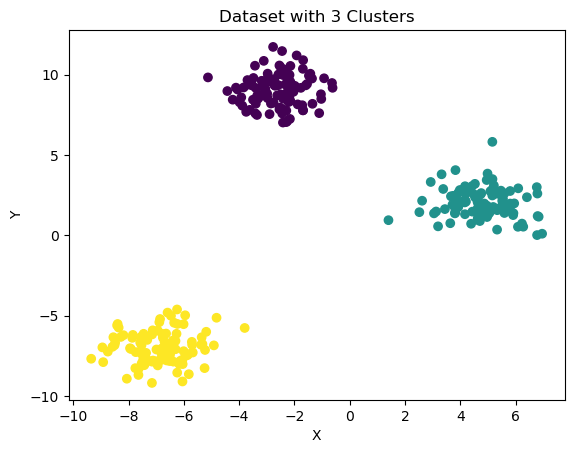

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 3 Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

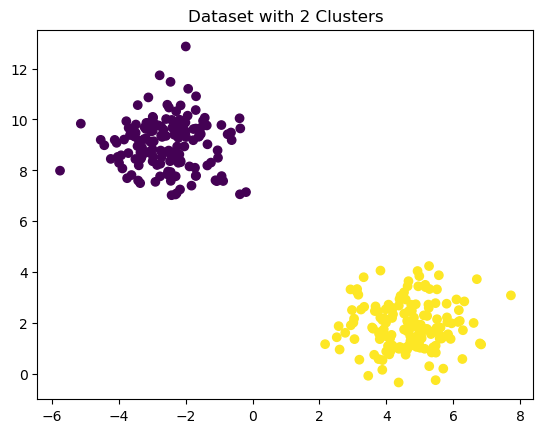

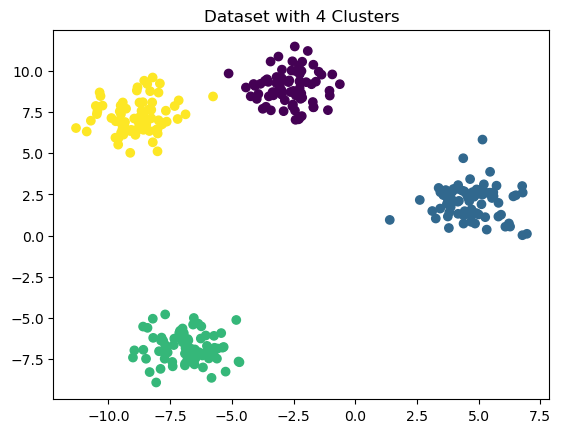

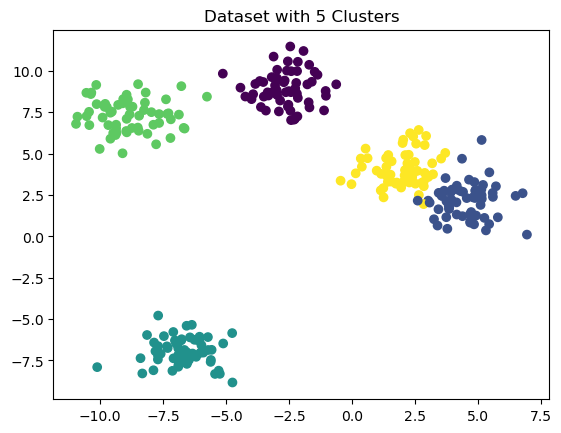

In [2]:
X, y = make_blobs(n_samples=300, centers=2, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 2 Clusters')
plt.show()

X, y = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 4 Clusters')
plt.show()

X, y = make_blobs(n_samples=300, centers=5, n_features=2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Dataset with 5 Clusters')
plt.show()

---
## Lab 2: Determine the optimal number of clusters using Elbow Method

### Question:
a) Generate a dataset using make_blobs().
b) Apply K-Means for different values of k (k=1 to 9).
c) Calculate inertia (sum of squared distances).
d) Plot the Elbow graph.

k=1, Inertia=20402.34444292629
k=2, Inertia=5763.464789461437
k=3, Inertia=566.859551124413
k=4, Inertia=497.033988149521
k=5, Inertia=428.21421299328415
k=6, Inertia=375.0659248776244
k=7, Inertia=308.19836610418247
k=8, Inertia=272.4057314987481
k=9, Inertia=234.28072349591133


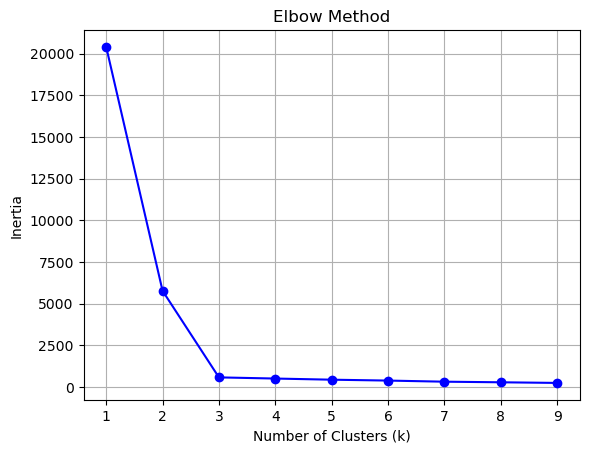

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

inertias = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    print(f"k={k}, Inertia={kmeans.inertia_}")

plt.plot(range(1, 10), inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

---
## Lab 3: Perform clustering using K-Means on a synthetic dataset

### Question:
a) Generate a dataset using make_blobs().
b) Apply the K-Means algorithm.
c) Change the number of clusters from 2 to 5.
d) Plot clusters and centroids.
e) Observe how cluster formation changes.

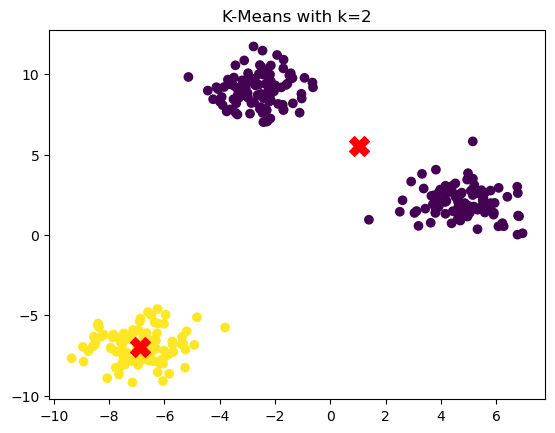

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=2')
plt.show()

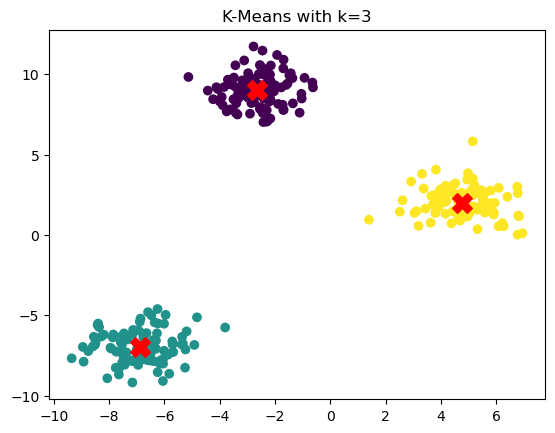

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=3')
plt.show()

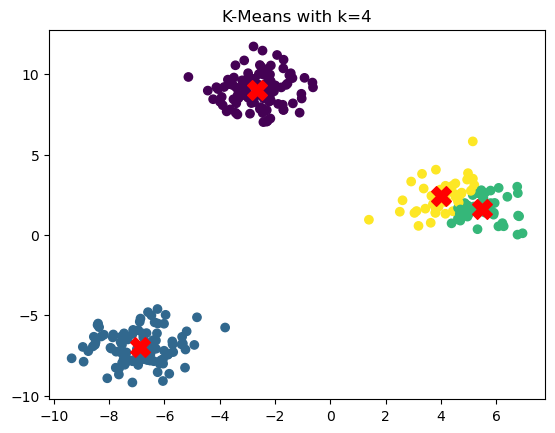

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=4')
plt.show()

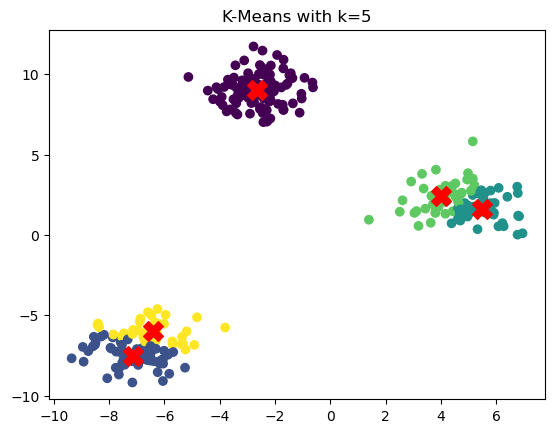

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means with k=5')
plt.show()

---
## Lab 4: Perform clustering using Hierarchical Clustering on a synthetic dataset

### Question:
a) Generate a dataset using make_blobs().
b) Apply Agglomerative Clustering.
c) Plot a dendrogram.
d) Compare results with K-Means clustering.

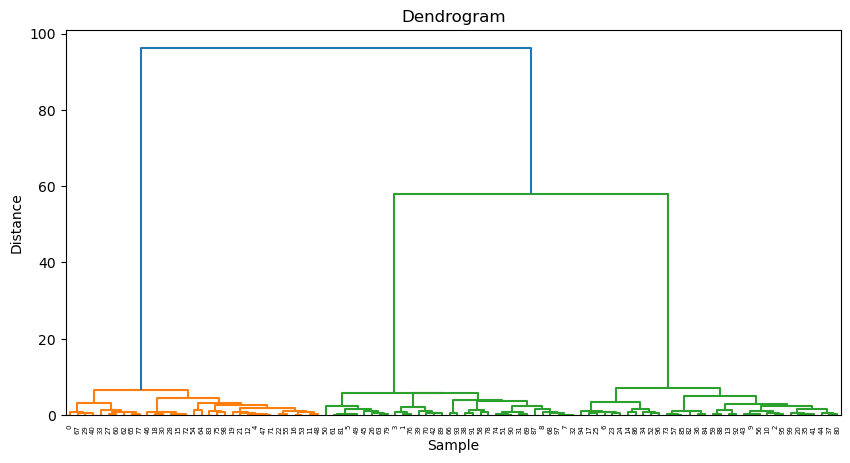

In [8]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

linkage_matrix = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.show()

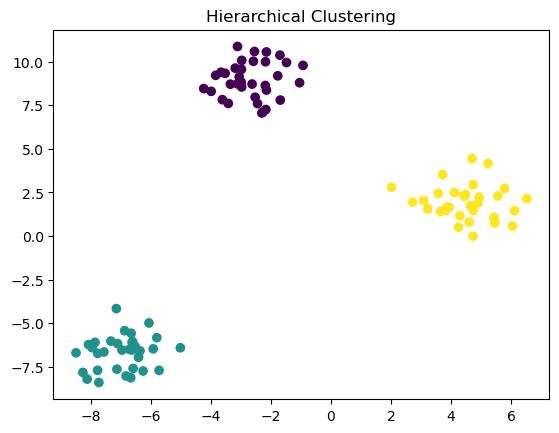

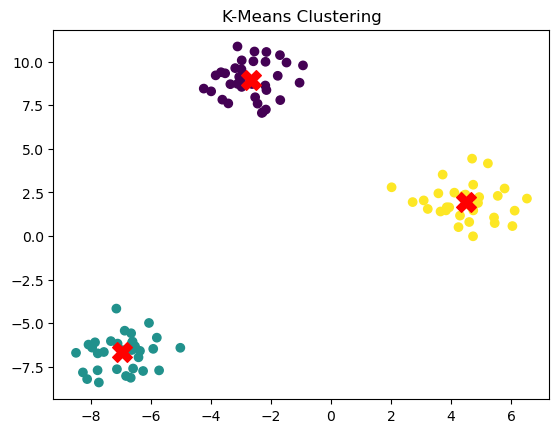

In [9]:
agg_cluster = AgglomerativeClustering(n_clusters=3)
labels_agg = agg_cluster.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_agg)
plt.title('Hierarchical Clustering')
plt.show()

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
plt.title('K-Means Clustering')
plt.show()

---
## Lab 5: Find patterns using association rules

### Question:
a) Create a small transaction dataset.
b) Apply the Apriori algorithm.
c) Calculate support and confidence.
d) Generate association rules.

In [10]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

transactions = [
    ['bread', 'milk'],
    ['bread', 'butter'],
    ['milk', 'butter'],
    ['bread', 'milk', 'butter'],
    ['bread', 'milk'],
    ['milk', 'butter']
]

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("Transaction Data:")
print(df)
print()

Transaction Data:
   bread  butter   milk
0   True   False   True
1   True    True  False
2  False    True   True
3   True    True   True
4   True   False   True
5  False    True   True



In [12]:
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)

print("Frequent Itemsets:")
print(frequent_itemsets)
print()

Frequent Itemsets:
    support         itemsets
0  0.666667          (bread)
1  0.666667         (butter)
2  0.833333           (milk)
3  0.333333  (butter, bread)
4  0.500000    (bread, milk)
5  0.500000   (butter, milk)



In [13]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("Association Rules:")
print()
for index, row in rules.iterrows():
    print(f"Rule: {row['antecedents']} => {row['consequents']}")
    print(f"Support: {row['support']:.2f}")
    print(f"Confidence: {row['confidence']:.2f}")
    print()

Association Rules:

Rule: frozenset({'butter'}) => frozenset({'bread'})
Support: 0.33
Confidence: 0.50

Rule: frozenset({'bread'}) => frozenset({'butter'})
Support: 0.33
Confidence: 0.50

Rule: frozenset({'bread'}) => frozenset({'milk'})
Support: 0.50
Confidence: 0.75

Rule: frozenset({'milk'}) => frozenset({'bread'})
Support: 0.50
Confidence: 0.60

Rule: frozenset({'butter'}) => frozenset({'milk'})
Support: 0.50
Confidence: 0.75

Rule: frozenset({'milk'}) => frozenset({'butter'})
Support: 0.50
Confidence: 0.60



---
## Lab 6: Implement Artificial Neuron Calculation

### Question:
a) Take input values x1, x2, x3.
b) Assign weights w1, w2, w3.
c) Compute neuron output using: y=f(w1x1+w2x2+w3x3+b)
d) Implement it using activation functions: step, sigmoid, tanh, relu

In [14]:
import numpy as np

x1 = 1
x2 = 2
x3 = 3

w1 = 0.5
w2 = 0.3
w3 = 0.2

bias = 0.1

z = w1*x1 + w2*x2 + w3*x3 + bias

print(f"Inputs: x1={x1}, x2={x2}, x3={x3}")
print(f"Weights: w1={w1}, w2={w2}, w3={w3}")
print(f"Bias: {bias}")
print(f"Weighted Sum: {z}")
print()

Inputs: x1=1, x2=2, x3=3
Weights: w1=0.5, w2=0.3, w3=0.2
Bias: 0.1
Weighted Sum: 1.8000000000000003



In [15]:
if z >= 0:
    step_output = 1
else:
    step_output = 0

print(f"Step Function Output: {step_output}")

Step Function Output: 1


In [16]:
sigmoid_output = 1 / (1 + np.exp(-z))

print(f"Sigmoid Output: {sigmoid_output}")

Sigmoid Output: 0.8581489350995123


In [17]:
tanh_output = np.tanh(z)

print(f"Tanh Output: {tanh_output}")

Tanh Output: 0.9468060128462683


In [18]:
if z >= 0:
    relu_output = z
else:
    relu_output = 0

print(f"ReLU Output: {relu_output}")

ReLU Output: 1.8000000000000003


---
## Lab 7: Train a perceptron classifier on a synthetic dataset

### Question:
a) Generate a dataset using make_classification().
b) Train a perceptron classifier.
c) Plot the decision boundary.
d) Identify misclassified points and compute accuracy.

In [19]:
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=100, n_features=2, n_informative=2, 
                          n_redundant=0, random_state=42)

perceptron = Perceptron(max_iter=100, random_state=42)
perceptron.fit(X, y)

y_pred = perceptron.predict(X)

accuracy = sum(y == y_pred) / len(y)

print(f"Accuracy: {accuracy}")
print()

Accuracy: 0.98



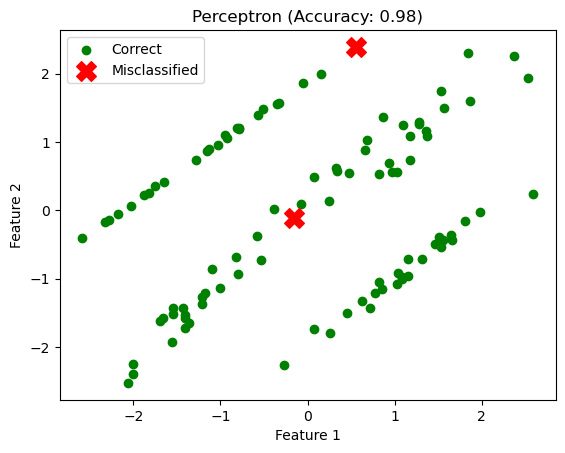

Number of Misclassified Points: 2


In [20]:
misclassified = y != y_pred

plt.scatter(X[~misclassified, 0], X[~misclassified, 1], c='green', label='Correct')
plt.scatter(X[misclassified, 0], X[misclassified, 1], c='red', marker='X', s=200, label='Misclassified')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Perceptron (Accuracy: {accuracy})')
plt.legend()
plt.show()

print(f"Number of Misclassified Points: {sum(misclassified)}")

---
## Lab 8: Implement a neural network classifier using MLPClassifier

### Question:
a) Create a dataset.
b) Train a neural network classifier.
c) Change number of hidden layers.
d) Compare model accuracy.

In [21]:
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=200, n_features=10, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training different architectures:")
print()

Training different architectures:



In [22]:
mlp1 = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
mlp1.fit(X_train, y_train)
acc1 = mlp1.score(X_test, y_test)
print(f"Architecture (5,): Accuracy = {acc1}")

Architecture (5,): Accuracy = 0.75


In [23]:
mlp2 = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp2.fit(X_train, y_train)
acc2 = mlp2.score(X_test, y_test)
print(f"Architecture (10,): Accuracy = {acc2}")

Architecture (10,): Accuracy = 0.775


In [24]:
mlp3 = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
mlp3.fit(X_train, y_train)
acc3 = mlp3.score(X_test, y_test)
print(f"Architecture (10, 5): Accuracy = {acc3}")

Architecture (10, 5): Accuracy = 0.775


/home/iteradmin/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
mlp4 = MLPClassifier(hidden_layer_sizes=(15, 10, 5), max_iter=1000, random_state=42)
mlp4.fit(X_train, y_train)
acc4 = mlp4.score(X_test, y_test)
print(f"Architecture (15, 10, 5): Accuracy = {acc4}")

Architecture (15, 10, 5): Accuracy = 0.775


/home/iteradmin/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


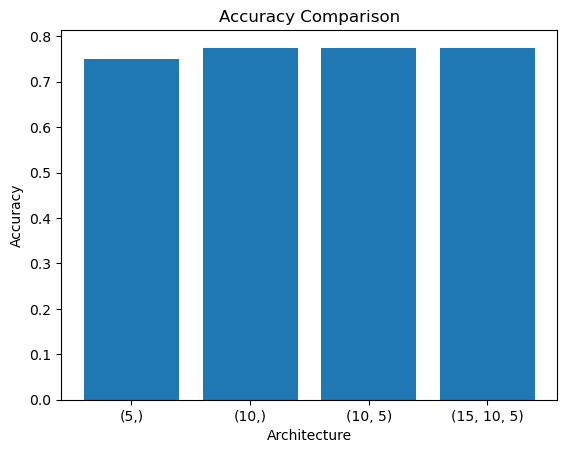

In [26]:
import matplotlib.pyplot as plt

architectures = ['(5,)', '(10,)', '(10, 5)', '(15, 10, 5)']
accuracies = [acc1, acc2, acc3, acc4]

plt.bar(architectures, accuracies)
plt.ylabel('Accuracy')
plt.xlabel('Architecture')
plt.title('Accuracy Comparison')
plt.show()

---
## Lab 9: Design a neural network with one hidden layer and train using backpropagation

### Question:
a) Create a dataset with two classes.
b) Design neural network: input layer, one hidden layer, output layer.
c) Perform forward propagation.
d) Apply backpropagation to train and evaluate accuracy.

In [27]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=100, n_features=2, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print()

ValueError: Number of informative, redundant and repeated features must sum to less than the number of total features

In [ ]:
np.random.seed(42)

w1 = np.random.randn(2, 3) * 0.01
b1 = np.zeros((1, 3))
w2 = np.random.randn(3, 1) * 0.01
b2 = np.zeros((1, 1))

print("Network initialized")
print(f"w1 shape: {w1.shape}")
print(f"w2 shape: {w2.shape}")
print()

In [ ]:
learning_rate = 0.1
epochs = 100

for epoch in range(epochs):
    z1 = np.dot(X_train, w1) + b1
    a1 = 1 / (1 + np.exp(-z1))
    
    z2 = np.dot(a1, w2) + b2
    a2 = 1 / (1 + np.exp(-z2))
    
    y_train_reshaped = y_train.reshape(-1, 1)
    
    dz2 = a2 - y_train_reshaped
    dw2 = np.dot(a1.T, dz2) / len(y_train)
    db2 = np.mean(dz2)
    
    da1 = np.dot(dz2, w2.T)
    dz1 = da1 * a1 * (1 - a1)
    dw1 = np.dot(X_train.T, dz1) / len(y_train)
    db1 = np.mean(dz1, axis=0)
    
    w2 -= learning_rate * dw2
    b2 -= learning_rate * db2
    w1 -= learning_rate * dw1
    b1 -= learning_rate * db1

print("Training completed")
print()

In [ ]:
z1 = np.dot(X_test, w1) + b1
a1 = 1 / (1 + np.exp(-z1))
z2 = np.dot(a1, w2) + b2
a2 = 1 / (1 + np.exp(-z2))

y_pred = (a2 > 0.5).astype(int).flatten()

accuracy = sum(y_test == y_pred) / len(y_test)

print(f"Accuracy: {accuracy}")
print(f"Correct predictions: {sum(y_test == y_pred)}")
print(f"Wrong predictions: {sum(y_test != y_pred)}")

---
## Lab 10: Complete ML Workflow

### Question:
a) Generate dataset.
b) Perform clustering to identify patterns.
c) Train perceptron classifier.
d) Train neural network classifier.
e) Compare results.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("=" * 50)
print("STEP A: GENERATE DATASET")
print("=" * 50)

X, y = make_classification(n_samples=200, n_features=5, n_classes=2, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")
print()

In [ ]:
print("=" * 50)
print("STEP B: CLUSTERING")
print("=" * 50)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

print(f"Number of clusters: 2")
print(f"Cluster 0 size: {sum(clusters == 0)}")
print(f"Cluster 1 size: {sum(clusters == 1)}")
print()

In [ ]:
print("=" * 50)
print("SPLIT DATA INTO TRAIN AND TEST")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print()

In [ ]:
print("=" * 50)
print("STEP C: TRAIN PERCEPTRON")
print("=" * 50)

perceptron = Perceptron(max_iter=100, random_state=42)
perceptron.fit(X_train, y_train)

y_pred_perc = perceptron.predict(X_test)
accuracy_perc = sum(y_test == y_pred_perc) / len(y_test)

print(f"Perceptron Accuracy: {accuracy_perc}")
print()

In [ ]:
print("=" * 50)
print("STEP D: TRAIN NEURAL NETWORK")
print("=" * 50)

mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
accuracy_mlp = sum(y_test == y_pred_mlp) / len(y_test)

print(f"Neural Network Accuracy: {accuracy_mlp}")
print()

In [ ]:
print("=" * 50)
print("STEP E: COMPARE RESULTS")
print("=" * 50)

print(f"Perceptron Accuracy: {accuracy_perc}")
print(f"Neural Network Accuracy: {accuracy_mlp}")
print()

if accuracy_mlp > accuracy_perc:
    print(f"Neural Network is better by {accuracy_mlp - accuracy_perc}")
elif accuracy_perc > accuracy_mlp:
    print(f"Perceptron is better by {accuracy_perc - accuracy_mlp}")
else:
    print("Both models have same accuracy")

In [ ]:
models = ['Perceptron', 'Neural Network']
accuracies = [accuracy_perc, accuracy_mlp]

plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])
plt.show()